# **NBA Injury Risk Modeling - Final Report**





---


**Project Title:** NBA Injury Risk Modeling

**Group Name:** The Analysts

**Group Members:** Karan Vohra, Srija Kethireddy, Sujit Mandava, Mateusz Gabrys


# **Introduction**

Player health and injuries play a critical role at all levels of sport, but particularly in professional basketball where the physical demands are intense and the competition schedule is grueling. Professional NBA teams face a constant challenge: balancing long-term player health with short-term winning objectives. A single injury to a star player can dramatically alter a team's championship prospects, cost millions in medical expenses, and potentially shorten a player's career.

This project aims to provide a data driven approach to injury risk management by developing predictive models that can quantify individual player injury risk and identify the key contributing factors. Our analysis focuses on three primary objectives:
1. Quantifying individual injury risk by predicting the probability of a player sustaining an injury within the next game or week based on workload and contextual features

2. Identifying which risk factors such as age, minutes played, and prior injury history contribute most significantly to injury likelihood

3. Developing team-level health metrics that aggregate player predictions into actionable insights for coaching staff



# **Datasets**
Our analysis utilizes three comprehensive datasets sourced from Kaggle, all derived from official NBA records, Pro Sports Transactions, and Basketball Reference.

The first dataset, **NBA Player Injury Stats (1951-2023)**, contains detailed injury records spanning over seven decades of professional basketball. This dataset includes approximately 18,000 documented injury events with information about the injury date, affected player, team, and injury description.

The second dataset, **NBA Box Scores & Stats (1947-Today)**, provides comprehensive game-level performance statistics for every player appearance. Each entry includes detailed performance metrics such as minutes played, points scored, assists, rebounds, shooting percentages, turnovers, fouls, steals, and blocks. The dataset also captures contextual information including game date, home/away status, opponent, and win/loss outcomes.

The third dataset, **NBA Players Bio Data (1996-2022)**, contains physical characteristics and demographic information for NBA players including height, weight, age, position, college attended, country of origin, and draft information.

Our analysis focuses on the time period from the 2000-2001 season through the 2022-2023 season, encompassing 23 seasons of modern NBA basketball. This was chosen to preserve recency bias as the game has evolved significantly in terms of pace, playing style, and physical demands.

Data Access: The preprocessed dataset is hosted publicly at: https://drive.google.com/file/d/1XIJ1DjvMN1eKEZOZPf_qhCEBAjnNNso0/view?usp=sharing

Original datasets available from Kaggle:

NBA Injury Stats: https://www.kaggle.com/datasets/loganlauton/nba-injury-stats-1951-2023

NBA Box Scores: https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores/?select=PlayerStatistics.csv

NBA Bio Data: https://www.kaggle.com/datasets/justinas/nba-players-data?select=all_seasons.csv

# **Exploratory Data Analysis & Preprocessing**

The data preprocessing phase presented several significant challenges. We had to ensure data integrity while maintaining the richness of information needed for accurate injury prediction. Our preprocessing pipeline consisted of five major stages: normalization and ID assignment, data cleaning, filtering, feature engineering, and handling class imbalance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import roc_auc_score, roc_curve
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
player_statistics = pd.read_csv('/content/drive/MyDrive/datascience/PlayerStatistics.csv')
games = pd.read_csv('/content/drive/MyDrive/datascience/Games.csv')
player_bio = pd.read_csv('/content/drive/MyDrive/datascience/all_seasons.csv')
players= pd.read_csv('/content/drive/MyDrive/datascience/Players.csv')
injury= pd.read_csv('/content/drive/MyDrive/datascience/NBA Player Injury Stats(1951 - 2023)_final.csv')
player_bio = player_bio.rename(columns={'season': 'season_game'})


/tmp/ipython-input-1745398733.py:1: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  player_statistics = pd.read_csv('/content/drive/MyDrive/datascience/PlayerStatistics.csv')
/tmp/ipython-input-1745398733.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv('/content/drive/MyDrive/datascience/Games.csv')


## Data Cleaning and Normalization
**Normalization and ID Assignment:** The first step involved processing team and player names to normalize them across the three datasets because player names appeared in various formats. We assigned identifiers to each player (personId), game (gameId), and team (teamId) to join the datasets.

**Data Cleaning:** We identified approximately 1,000 rows where player names in the performance dataset could not be matched to entries in the injury dataset. These records were removed. We also dropped approximately 400 rows with missing player height and weight information.

In [ ]:
def standardize_season(season):
    if '-' in str(season):
        parts = season.split('-')
        if len(parts[1]) == 2:
            first_year = parts[0]
            second_year = first_year[:2] + parts[1]
            return f"{first_year}-{second_year}"
    return season

player_bio['season_game'] = player_bio['season_game'].apply(standardize_season)

In [ ]:
display(injury.head())

,Unnamed: 0,Date,Team,Acquired,Relinquished,Notes,relinquished_player_id
0,3208,1999-02-02,Kings,NaN,Chris Robinson,placed on IL,997.0
1,3209,1999-02-02,Kings,NaN,Ray Owes,placed on IL,1077.0
2,3210,1999-02-03,76ers,NaN,Darrin Hancock,placed on IL with bruised left thigh,241.0
3,3211,1999-02-03,Cavaliers,NaN,Ryan Stack,placed on IR with fractured finger,1756.0
4,3212,1999-02-03,Heat,NaN,Terry Mills,placed on IL with sore left knee,371.0


In [ ]:
injury = player_bio.rename(columns={'relinquished_player_id': 'personId'})
injury = player_bio.rename(columns={'Relinquished': 'player_name'})

In [ ]:
display(player_statistics.head())

,firstName,lastName,personId,gameId,gameDate,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,James,Johnson,201949,42400407,2025-06-22 20:00:00,Indiana,Pacers,Oklahoma City,Thunder,Playoffs,...,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
1,T.J.,McConnell,204456,42400407,2025-06-22 20:00:00,Indiana,Pacers,Oklahoma City,Thunder,Playoffs,...,0.000,0.0,0.0,0.000,6.0,0.0,6.0,2.0,7.0,-12.0
2,Myles,Turner,1626167,42400407,2025-06-22 20:00:00,Indiana,Pacers,Oklahoma City,Thunder,Playoffs,...,0.333,4.0,1.0,0.250,3.0,1.0,4.0,3.0,1.0,-12.0
3,Pascal,Siakam,1627783,42400407,2025-06-22 20:00:00,Indiana,Pacers,Oklahoma City,Thunder,Playoffs,...,0.400,7.0,4.0,0.571,3.0,1.0,4.0,2.0,1.0,-4.0
4,Alex,Caruso,1627936,42400407,2025-06-22 20:00:00,Oklahoma City,Thunder,Indiana,Pacers,Playoffs,...,0.400,0.0,0.0,0.000,1.0,2.0,3.0,3.0,0.0,8.0


In [ ]:
display((games).head())

,gameId,gameDate,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,attendance,arenaId,gameLabel,gameSubLabel,seriesGameNumber
0,42400407,2025-06-22 20:00:00,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,103,91,1610612760,Playoffs,18203.0,1000052,NBA Finals,Game 7,7.0
1,42400406,2025-06-19 20:30:00,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,108,91,1610612754,Playoffs,17274.0,1000063,NBA Finals,Game 6,6.0
2,42400405,2025-06-16 20:30:00,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,120,109,1610612760,Playoffs,18203.0,1000052,NBA Finals,Game 5,5.0
3,42400404,2025-06-13 20:30:00,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,104,111,1610612760,Playoffs,17274.0,1000063,NBA Finals,Game 4,4.0
4,42400403,2025-06-11 20:30:00,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,116,107,1610612754,Playoffs,17274.0,1000063,NBA Finals,Game 3,3.0


In [ ]:
display(player_bio.head())

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season_game
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-1997
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-1997
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-1997
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-1997
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-1997


In [ ]:
display(players.head())

,personId,firstName,lastName,birthdate,lastAttended,country,height,bodyWeight,guard,forward,center,draftYear,draftRound,draftNumber
0,2,Byron,Scott,1961-03-28,Arizona State,USA,76.0,205.0,True,False,False,1983.0,1.0,4.0
1,3,Grant,Long,1966-03-12,Eastern Michigan,USA,81.0,3.0,False,False,False,1988.0,2.0,33.0
2,7,Dan,Schayes,1959-05-10,Syracuse,USA,83.0,260.0,False,False,True,1981.0,1.0,13.0
3,9,Sedale,Threatt,1961-09-10,West Virginia Tech,USA,74.0,185.0,True,False,False,1983.0,6.0,139.0
4,12,Chris,King,1969-07-24,Wake Forest,USA,80.0,215.0,False,True,False,1992.0,2.0,45.0


In [ ]:
print(f"player_bio: " ,(player_bio.columns))
print("player_statistics: ", (player_statistics.columns))
print("games: ",(games.columns))
print("players: ",(players.columns))
print("injury: ",(injury.columns))

player_bio:  Index(['Unnamed: 0', 'player_name', 'team_abbreviation', 'age',
       'player_height', 'player_weight', 'college', 'country', 'draft_year',
       'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating',
       'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season_game'],
      dtype='object')
player_statistics:  Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDate',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints'],
    

In [ ]:
def get_position(row):
    positions = []
    if row['guard'] == True:
        positions.append('guard')
    if row['forward'] == True:
        positions.append('forward')
    if row['center'] == True:
        positions.append('center')
    return '/'.join(positions) if positions else 'unknown'

players['position'] = players.apply(get_position, axis=1)

In [ ]:
player_statistics['gameDate'] = pd.to_datetime(player_statistics['gameDate'])

In [ ]:
def get_season(date):
    year = date.year
    month = date.month
    if month >= 10:
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

player_statistics['season'] = player_statistics['gameDate'].apply(get_season)

In [ ]:
player_statistics['season_game'] = player_statistics['gameDate'].apply(get_season)

In [ ]:
seasons_to_keep = [f"{year}-{year+1}" for year in range(2000, 2023)]
player_statistics = player_statistics[player_statistics['season'].isin(seasons_to_keep)].copy()

In [ ]:
player_statistics['player_name'] = player_statistics['firstName'] + ' ' + player_statistics['lastName']

In [ ]:
bio_cols = ['player_name', 'season_game', 'player_height', 'player_weight', 'age']

player_bio_subset = player_bio[bio_cols].copy()

In [ ]:
players_subset = players[['personId', 'position']].copy()

In [ ]:
games['gameDate'] = pd.to_datetime(games['gameDate'])
games['season'] = games['gameDate'].apply(get_season)
games_subset = games[games['season'].isin(seasons_to_keep)].copy()

In [ ]:
games_subset = games_subset.drop(columns=['season'])
combined = player_statistics.merge(games_subset, on='gameId', how='left', suffixes=('_player', '_game'))

In [ ]:
print((combined.shape))
display(combined.head())


(781108, 54)


,firstName,lastName,personId,gameId,gameDate_player,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType_player,...,awayteamId,homeScore,awayScore,winner,gameType_game,attendance,arenaId,gameLabel_game,gameSubLabel_game,seriesGameNumber_game
0,Udonis,Haslem,2617,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,1610612748,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0
1,Kyle,Lowry,200768,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,1610612748,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0
2,Jeff,Green,201145,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,1610612748,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0
3,Kevin,Love,201567,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,1610612748,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0
4,DeAndre,Jordan,201599,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,1610612748,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0


In [ ]:
combined = combined.merge(players_subset, on='personId', how='left')

In [ ]:
print((combined.shape))
display(combined.head())

(781108, 55)


,firstName,lastName,personId,gameId,gameDate_player,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType_player,...,homeScore,awayScore,winner,gameType_game,attendance,arenaId,gameLabel_game,gameSubLabel_game,seriesGameNumber_game,position
0,Udonis,Haslem,2617,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward
1,Kyle,Lowry,200768,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,unknown
2,Jeff,Green,201145,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward
3,Kevin,Love,201567,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward
4,DeAndre,Jordan,201599,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,94,89,1610612743,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,center


In [ ]:
combined = combined.merge(player_bio_subset, on=['player_name', 'season_game'], how='left')

In [ ]:
print((combined.shape))
display(combined.head())

(781371, 58)


,firstName,lastName,personId,gameId,gameDate_player,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType_player,...,gameType_game,attendance,arenaId,gameLabel_game,gameSubLabel_game,seriesGameNumber_game,position,player_height,player_weight,age
0,Udonis,Haslem,2617,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward,200.66,106.594120,43.0
1,Kyle,Lowry,200768,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,unknown,182.88,88.904032,37.0
2,Jeff,Green,201145,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward,203.20,106.594120,36.0
3,Kevin,Love,201567,42200405,2023-06-12 20:30:00,Miami,Heat,Denver,Nuggets,Playoffs,...,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,forward,203.20,113.851592,34.0
4,DeAndre,Jordan,201599,42200405,2023-06-12 20:30:00,Denver,Nuggets,Miami,Heat,Playoffs,...,Playoffs,19537.0,1000046,NBA Finals,NaN,5.0,center,210.82,120.201880,34.0


In [ ]:
for column in combined.columns:
    print(f"{column}")

firstName
lastName
personId
gameId
gameDate_player
playerteamCity
playerteamName
opponentteamCity
opponentteamName
gameType_player
gameLabel_player
gameSubLabel_player
seriesGameNumber_player
win
home
numMinutes
points
assists
blocks
steals
fieldGoalsAttempted
fieldGoalsMade
fieldGoalsPercentage
threePointersAttempted
threePointersMade
threePointersPercentage
freeThrowsAttempted
freeThrowsMade
freeThrowsPercentage
reboundsDefensive
reboundsOffensive
reboundsTotal
foulsPersonal
turnovers
plusMinusPoints
season
season_game
player_name
gameDate_game
hometeamCity
hometeamName
hometeamId
awayteamCity
awayteamName
awayteamId
homeScore
awayScore
winner
gameType_game
attendance
arenaId
gameLabel_game
gameSubLabel_game
seriesGameNumber_game
position
player_height
player_weight
age


In [ ]:
final_columns = [
    "personId",
    "player_name",
    "gameId",
    "gameDate_player",
    "win",
    "home",
    "season",
    "season_game",
    "numMinutes",
    "points",
    "assists",
    "reboundsDefensive",
    "reboundsOffensive",
    "threePointersAttempted",
    "threePointersMade",
    "fieldGoalsAttempted",
    "fieldGoalsMade",
    "freeThrowsAttempted",
    "freeThrowsMade",
    "turnovers",
    "plusMinusPoints",
    "foulsPersonal",
    "steals",
    "blocks",
    "player_height",
    "player_weight",
    "age",
    "position",
    "playerteamCity",
    "playerteamName",
    "opponentteamCity",
    "opponentteamName",
]


combined_final = combined[final_columns].copy()

In [ ]:
print((combined_final.shape))
display(combined_final.head())


(781371, 32)


,personId,player_name,gameId,gameDate_player,win,home,season,season_game,numMinutes,points,...,steals,blocks,player_height,player_weight,age,position,playerteamCity,playerteamName,opponentteamCity,opponentteamName
0,2617,Udonis Haslem,42200405,2023-06-12 20:30:00,0,0,2022-2023,2022-2023,NaN,0.0,...,0.0,0.0,200.66,106.594120,43.0,forward,Miami,Heat,Denver,Nuggets
1,200768,Kyle Lowry,42200405,2023-06-12 20:30:00,0,0,2022-2023,2022-2023,34.0,12.0,...,2.0,1.0,182.88,88.904032,37.0,unknown,Miami,Heat,Denver,Nuggets
2,201145,Jeff Green,42200405,2023-06-12 20:30:00,1,1,2022-2023,2022-2023,4.0,4.0,...,0.0,0.0,203.20,106.594120,36.0,forward,Denver,Nuggets,Miami,Heat
3,201567,Kevin Love,42200405,2023-06-12 20:30:00,0,0,2022-2023,2022-2023,14.0,3.0,...,1.0,2.0,203.20,113.851592,34.0,forward,Miami,Heat,Denver,Nuggets
4,201599,DeAndre Jordan,42200405,2023-06-12 20:30:00,1,1,2022-2023,2022-2023,3.0,0.0,...,0.0,1.0,210.82,120.201880,34.0,center,Denver,Nuggets,Miami,Heat


In [ ]:
print("final dataset: ", (combined_final.columns))

final dataset:  Index(['personId', 'player_name', 'gameId', 'gameDate_player', 'win', 'home',
       'season', 'season_game', 'numMinutes', 'points', 'assists',
       'reboundsDefensive', 'reboundsOffensive', 'threePointersAttempted',
       'threePointersMade', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'freeThrowsAttempted', 'freeThrowsMade', 'turnovers', 'plusMinusPoints',
       'foulsPersonal', 'steals', 'blocks', 'player_height', 'player_weight',
       'age', 'position', 'playerteamCity', 'playerteamName',
       'opponentteamCity', 'opponentteamName'],
      dtype='object')


In [ ]:
print(combined_final.isnull().sum())

personId                       0
player_name                    0
gameId                         0
gameDate_player                0
win                            0
home                           0
season                         0
season_game                    0
numMinutes                129930
points                      1219
assists                     1219
reboundsDefensive           1219
reboundsOffensive           1219
threePointersAttempted      1219
threePointersMade           1219
fieldGoalsAttempted         1219
fieldGoalsMade              1219
freeThrowsAttempted         1219
freeThrowsMade              1219
turnovers                   1219
plusMinusPoints             1219
foulsPersonal               1219
steals                      1219
blocks                      1219
player_height              11166
player_weight              11166
age                        11166
position                       0
playerteamCity                 0
playerteamName                 0
opponentte

In [ ]:
combined_final.to_csv('injury_analysis_preprocessed.csv', index=False)

In [ ]:
print(player_statistics['season'].unique())

['2022-2023' '2021-2022' '2020-2021' '2019-2020' '2018-2019' '2017-2018'
 '2016-2017' '2015-2016' '2014-2015' '2013-2014' '2012-2013' '2011-2012'
 '2010-2011' '2009-2010' '2008-2009' '2007-2008' '2006-2007' '2005-2006'
 '2004-2005' '2003-2004' '2002-2003' '2001-2002' '2000-2001']


In [ ]:
# non_injury= pd.read_csv('/content/drive/MyDrive/datascience/final_dataset.csv')injury_analysis_preprocessed.csv
non_injury= pd.read_csv('injury_analysis_preprocessed.csv')

In [ ]:
print("non-injury: ",(non_injury.columns))

non-injury:  Index(['personId', 'player_name', 'gameId', 'gameDate_player', 'win', 'home',
       'season', 'season_game', 'numMinutes', 'points', 'assists',
       'reboundsDefensive', 'reboundsOffensive', 'threePointersAttempted',
       'threePointersMade', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'freeThrowsAttempted', 'freeThrowsMade', 'turnovers', 'plusMinusPoints',
       'foulsPersonal', 'steals', 'blocks', 'player_height', 'player_weight',
       'age', 'position', 'playerteamCity', 'playerteamName',
       'opponentteamCity', 'opponentteamName'],
      dtype='object')


In [ ]:
injury= pd.read_csv('/content/drive/MyDrive/datascience/NBA Player Injury Stats(1951 - 2023)_final.csv')

In [ ]:
injury = injury.rename(columns={'relinquished_player_id': 'personId'})
injury = injury.rename(columns={'Relinquished': 'player_name'})

In [ ]:
injury['Date'] = pd.to_datetime(injury['Date'])
injury = injury.rename(columns={'Date': 'injury_date'})


In [ ]:
print("non-injury: ",(injury.columns))

non-injury:  Index(['Unnamed: 0', 'injury_date', 'Team', 'Acquired', 'player_name', 'Notes',
       'personId'],
      dtype='object')


In [ ]:
non_injury['personId'] = non_injury['personId'].astype('int64')
injury['personId'] = injury['personId'].astype('int64')


In [ ]:
non_injury_sorted = non_injury.sort_values('gameDate_player')
injury_sorted = injury.sort_values('injury_date')

injury_sorted['injury_date'] = pd.to_datetime(injury_sorted['injury_date'])
non_injury_sorted['gameDate_player'] = pd.to_datetime(non_injury_sorted['gameDate_player'])

non_injury_sorted['gameDate_player'] = non_injury_sorted['gameDate_player'].dt.normalize()
injury_cols = ['personId', 'injury_date', 'Notes']

result = pd.merge(
    non_injury_sorted,
    injury_sorted[['personId', 'injury_date', 'Notes']],
    left_on=['personId', 'gameDate_player'],
    right_on=['personId', 'injury_date'],
    how='left'
)

In [ ]:
print(f"dataset shape: {result.shape}")
display(result.head())


dataset shape: (781371, 34)


,personId,player_name,gameId,gameDate_player,win,home,season,season_game,numMinutes,points,...,player_height,player_weight,age,position,playerteamCity,playerteamName,opponentteamCity,opponentteamName,injury_date,Notes
0,2069,Hanno Mottola,20000004,2000-10-31,0,1,2000-2001,2000-2001,30.0,10.0,...,210.82,112.037224,24.0,forward/center,Atlanta,Hawks,Charlotte,Hornets,NaT,NaN
1,1892,Trajan Langdon,20000002,2000-10-31,1,0,2000-2001,2000-2001,NaN,0.0,...,190.50,89.357624,25.0,unknown,Cleveland,Cavaliers,New Jersey,Nets,NaT,NaN
2,1915,Evan Eschmeyer,20000002,2000-10-31,0,1,2000-2001,2000-2001,27.0,1.0,...,210.82,115.665960,26.0,center,New Jersey,Nets,Cleveland,Cavaliers,NaT,NaN
3,2030,Kenyon Martin,20000002,2000-10-31,0,1,2000-2001,2000-2001,30.0,10.0,...,205.74,104.326160,23.0,forward,New Jersey,Nets,Cleveland,Cavaliers,NaT,NaN
4,2036,Chris Mihm,20000002,2000-10-31,1,0,2000-2001,2000-2001,3.0,0.0,...,215.90,120.201880,21.0,center,Cleveland,Cavaliers,New Jersey,Nets,NaT,NaN


In [ ]:
print(result.isnull().sum())
print(result.shape)

personId                       0
player_name                    0
gameId                         0
gameDate_player                0
win                            0
home                           0
season                         0
season_game                    0
numMinutes                129930
points                      1219
assists                     1219
reboundsDefensive           1219
reboundsOffensive           1219
threePointersAttempted      1219
threePointersMade           1219
fieldGoalsAttempted         1219
fieldGoalsMade              1219
freeThrowsAttempted         1219
freeThrowsMade              1219
turnovers                   1219
plusMinusPoints             1219
foulsPersonal               1219
steals                      1219
blocks                      1219
player_height              11166
player_weight              11166
age                        11166
position                       0
playerteamCity                 0
playerteamName                 0
opponentte

In [ ]:
# result.to_csv('/content/drive/MyDrive/datascience/FINAL.csv', index=False)
result.to_csv('injury_analysis_modelling_dataset.csv', index=False)

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/injury_analysis_modelling_dataset.csv')

In [ ]:
df['gameDate_player'] = pd.to_datetime(df['gameDate_player'])
df['injury_date'] = pd.to_datetime(df['injury_date'], errors='coerce')

df = df.sort_values(['personId', 'gameDate_player']).reset_index(drop=True)

df['injury_indicator'] = (
    df.groupby('personId')['injury_date']
      .transform(lambda s: s.ne(s.shift()) & s.notna())
).astype(int)

df['number_of_prior_injuries'] = (
    df.groupby('personId')['injury_indicator']
      .cumsum()
      .shift(fill_value=0)
)

df['true_injury_event_date'] = df['gameDate_player'].where(df['injury_indicator'] == 1)

# Forward-fill within each player to get "last injury event"
df['last_injury_event_date'] = (
    df.groupby('personId')['true_injury_event_date']
      .ffill()
)

# Calculate days since last injury
df['days_since_last_injury'] = (
    df['gameDate_player'] - df['last_injury_event_date']
).dt.days

# Before first injury
df['days_since_last_injury'] = df['days_since_last_injury'].fillna(-1)

df = df.drop(columns=['true_injury_event_date'])

numerical_cols = [
    'player_height', 'player_weight', 'age',
    'numMinutes', 'points', 'assists',
    'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal',
    'threePointersAttempted', 'threePointersMade',
    'fieldGoalsAttempted', 'fieldGoalsMade',
    'freeThrowsAttempted', 'freeThrowsMade',
    'turnovers', 'foulsPersonal', 'steals', 'blocks',
    'fieldGoalsPercentage', 'threePointersPercentage', 'freeThrowsPercentage',
    'plusMinusPoints'
]

# Impute missing numeric values with column medians
for col in numerical_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-2020069039.py:103: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
all_possible_categorical_cols = [
    'home', 'win'
]

categorical_cols_to_encode = [col for col in all_possible_categorical_cols if col in dataset.columns]
df = pd.get_dummies(df, columns=categorical_cols_to_encode, dummy_na=False)
df.sort_values(by=['personId', 'gameDate_player'], inplace=True)

In [ ]:
df['gameDate_player'] = pd.to_datetime(df['gameDate_player'])
df['season'] = df['gameDate_player'].dt.year

season_counts = (
    df.groupby(['personId', 'season'])['gameId']
      .nunique()
      .reset_index()
      .rename(columns={'gameId': 'games_played'})
)

# Minimum games required
MIN_GAMES = 24   # One quarter of the season

valid_seasons = season_counts[season_counts['games_played'] >= MIN_GAMES]
df = df.merge(valid_seasons[['personId', 'season']],
              on=['personId', 'season'],
              how='inner')

In [ ]:
df.to_csv('final_final_training_dataset.csv')

# **Feature Engineering, Hyperparameter Tuning, Model Training**

We created new features based on information from our dataset that will be useful in injury prediction such as rolling metrics of playtime, previous injuries, position, and other performance statistics. Our aim is for our model to predict an injury on the next game, given information from the previous game. With this approach, we ensure that there is no data leakage where it has access to information to event occuring in future games through the rolling windows. All aggregated statistics are shifted by one day/game to strictly take information from previous games, preventing data leakage. Given our large class imbalance, we chose to use a GBM classifier at it is better suited to deal with sparse data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/final_final_training_dataset.csv')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.metrics import roc_auc_score, roc_curve
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns

df["gameDate_player"] = pd.to_datetime(df["gameDate_player"])
if "injury_date" in df.columns:
    df["injury_date"] = pd.to_datetime(df["injury_date"])

df = df.sort_values(["personId", "gameDate_player"]).reset_index(drop=True)

df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

safe_cols = []
used = set()

for c in df.columns:
    new = re.sub(r"[^0-9a-zA-Z_]+", "_", c)
    orig_new = new
    k = 1
    while new in used:
        new = f"{orig_new}_{k}"
        k += 1
    used.add(new)
    safe_cols.append(new)

rename_map = dict(zip(df.columns, safe_cols))
df = df.rename(columns=rename_map)

position_label_cols = []

if "position" in df.columns:
    df["position_list"] = df["position"].apply(
        lambda x: x.split("/") if isinstance(x, str) and x != "unknown" else []
    )

    mlb = MultiLabelBinarizer()
    raw_binary = mlb.fit_transform(df["position_list"])

    # Prefixed columns (e.g. 'position_guard')
    position_label_cols = [f"position_{c}" for c in mlb.classes_]

    position_binary = pd.DataFrame(
        raw_binary,
        columns=position_label_cols,
        index=df.index,
    )

    # Attach one-hot columns
    df = pd.concat([df, position_binary], axis=1)

df["injury_probability"] = 0

if "injury_indicator" not in df.columns:
    raise ValueError("Expected column 'injury_indicator' not found in df.")

for pid in df.loc[df["injury_indicator"] == 1, "personId"].unique():
    event_dates = (
        df.loc[
            (df["personId"] == pid) & (df["injury_indicator"] == 1),
            "gameDate_player",
        ]
        .dropna()
        .unique()
    )

    for event_date in event_dates:
        event_date = pd.to_datetime(event_date)
        window_start = event_date - pd.Timedelta(days=7)

        mask = (
            (df["personId"] == pid)
            & (df["gameDate_player"] >= window_start)
            & (df["gameDate_player"] < event_date)   # strictly before
        )
        df.loc[mask, "injury_probability"] = 1


# Minutes-based workload features
if "minutes" in df.columns:
    df["minutes_shift"] = df.groupby("personId")["minutes"].shift(1)

    df["acute_workload"] = (
        df.groupby("personId")["minutes_shift"]
          .rolling(3).mean()
          .reset_index(level=0, drop=True)
    )
    df["chronic_workload"] = (
        df.groupby("personId")["minutes_shift"]
          .rolling(15).mean()
          .reset_index(level=0, drop=True)
    )
    df["acwr"] = df["acute_workload"] / (df["chronic_workload"] + 1e-6)

    df["workload_mean_10"] = (
        df.groupby("personId")["minutes_shift"]
          .rolling(10).mean()
          .reset_index(level=0, drop=True)
    )
    df["workload_std_10"] = (
        df.groupby("personId")["minutes_shift"]
          .rolling(10).std()
          .reset_index(level=0, drop=True)
    )
    df["workload_zscore"] = (
        (df["minutes_shift"] - df["workload_mean_10"]) /
        (df["workload_std_10"] + 1e-6)
    )

    df["minutes_delta_1"] = df.groupby("personId")["minutes_shift"].diff()
    df["minutes_delta_from_acute"] = df["minutes_shift"] - df["acute_workload"]

# Rest & schedule features
df["days_since_last_game"] = (
    df.groupby("personId")["gameDate_player"].diff().dt.days
)
df["is_b2b"] = (df["days_since_last_game"] == 1).astype(int)

if "minutes_shift" in df.columns:
    df["games_last_7"] = (
        df.groupby("personId")["minutes_shift"]
          .rolling(7).count()
          .reset_index(level=0, drop=True)
    )

# Recent injury history
df["recent_injury"] = df.groupby("personId")["injury_indicator"].shift(1)
df["recent_injury_10"] = (
    df.groupby("personId")["recent_injury"]
      .rolling(10).sum()
      .reset_index(level=0, drop=True)
)

# Performance trend
if "pra" in df.columns:
    df["pra_shift"] = df.groupby("personId")["pra"].shift(1)
    df["pra_trend_5"] = (
        df.groupby("personId")["pra_shift"]
          .rolling(5).mean()
          .reset_index(level=0, drop=True)
    )
    df["pra_change"] = df["pra_shift"] - df["pra_trend_5"]

# Usage
if "usage_rate" in df.columns:
    df["usage_shift"] = df.groupby("personId")["usage_rate"].shift(1)
    df["usage_volatility"] = (
        df.groupby("personId")["usage_shift"]
          .rolling(8).std()
          .reset_index(level=0, drop=True)
    )

# Age-minutes interaction
if "age" in df.columns and "minutes_shift" in df.columns:
    df["age_minutes_interaction"] = df["age"] * df["minutes_shift"]

# Rookie indicator
if "experience" in df.columns:
    df["is_rookie"] = (df["experience"] <= 1).astype(int)

# Columns to be removed
non_predictive_cols = [
    "personId", "player_name", "gameId", "season", "season_game",
    "playerteamCity", "playerteamName", "opponentteamCity",
    "opponentteamName",
    "position", "position_list", "center", "forward", "guard",
    "Notes", "last_injury_event_date",
]

forbidden_cols = {
    "injury_probability",
    "injury_indicator",
    "injury_event",
    "injury_date",
    "injury_type",
    "injury_type_simple",
    "inj_lower",
    "last_injury_event_date",
}

for col in df.columns:
    if "injury" in col.lower():
        forbidden_cols.add(col)

# Allow past injury history features back in
for c in ["recent_injury", "recent_injury_10"]:
    if c in forbidden_cols:
        forbidden_cols.remove(c)

# Drop duplicate columns
df = df.loc[:, ~df.columns.duplicated()]


# Final feature list
numeric_bool_cols = df.select_dtypes(include=["number", "bool"]).columns

predictive_features = [
    c for c in numeric_bool_cols
    if c not in non_predictive_cols and c not in forbidden_cols
]

predictive_features = [c for c in predictive_features if c in df.columns]

seen = set()
unique_features = []
for c in predictive_features:
    if c not in seen:
        unique_features.append(c)
        seen.add(c)
predictive_features = unique_features

safe_injury_history = {"recent_injury", "recent_injury_10"}
leakage_suspects = [
    c for c in predictive_features
    if "injury" in c.lower() and c not in safe_injury_history
]

print("Leakage check (should be empty):", leakage_suspects)

leaky = set(predictive_features) & forbidden_cols
assert not leaky, f"Leakage! predictive_features contains {leaky}"

print(f"Using {len(predictive_features)} predictive features.")


# Drop rows with missing values in any predictive feature
df = df.dropna(subset=predictive_features).copy()

# Keep only players with at least 24 games
game_counts = df.groupby("personId")["gameDate_player"].transform("count")
df = df[game_counts >= 24].copy()

print("After filtering, rows:", len(df))

# Train test split
split_date = pd.to_datetime("2022-01-01")
train_mask = df["gameDate_player"] < split_date
test_mask  = ~train_mask

X_train = df.loc[train_mask, predictive_features]
X_test  = df.loc[test_mask,  predictive_features]
y_train = df.loc[train_mask, "injury_probability"].astype(int)
y_test  = df.loc[test_mask,  "injury_probability"].astype(int)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("Positive rate in train:", y_train.mean())
print("Positive rate in test :", y_test.mean())


Leakage check (should be empty): []
Using 79 predictive features.
After filtering, rows: 735867
Train size: 682748, Test size: 53119
Positive rate in train: 0.01551817068669553
Positive rate in test : 0.030535213388806264


We now perform cross-validation stratified temporally to optimize the hyperparameters. This will create folds where the train set will be the 2003/4 -2004/5 season and the validation set will be the 2006/7 season. This ensures that there is no leakage due to random shuffling of data where future statistics can be learned.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

# Base model
lgbm_base = LGBMClassifier(
    boosting_type="gbdt",
    objective="binary",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

param_distributions = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.01, 0.02, 0.03],
    "num_leaves": [15, 31, 63],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_samples": [50, 75, 100],
    "reg_alpha": [0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 3.0],
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

random_search.fit(X_train, y_train)

print("Best CV ROC-AUC: {:.4f}".format(random_search.best_score_))
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Number of positive: 10595, number of negative: 672153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.138605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8697
[LightGBM] [Info] Number of data points in the train set: 682748, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015518 -> initscore=-4.150104
[LightGBM] [Info] Start training from score -4.150104
Best CV ROC-AUC: 0.7056
Best params:
  subsample: 0.7
  reg_lambda: 3.0
  reg_alpha: 1.0
  num_leaves: 15
  n_estimators: 300
  min_child_samples: 75
  max_depth: 8
  learning_rate: 0.01
  colsample_bytree: 0.8


In [ ]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

model = LGBMClassifier(
    boosting_type="gbdt",
    objective="binary",
    n_estimators=300,
    learning_rate=0.01,
    num_leaves=15,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    min_child_samples=75,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 10595, number of negative: 672153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.873737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8697
[LightGBM] [Info] Number of data points in the train set: 682748, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015518 -> initscore=-4.150104
[LightGBM] [Info] Start training from score -4.150104


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.01, max_depth=8,
               min_child_samples=75, n_estimators=300, n_jobs=-1, num_leaves=15,
               objective='binary', random_state=42, reg_alpha=1.0,
               reg_lambda=3.0, scale_pos_weight=np.float64(63.44058518168948),
               subsample=0.7)

#**Model Testing and Analysis**

Train ROC-AUC: 0.7515
Test  ROC-AUC: 0.7166


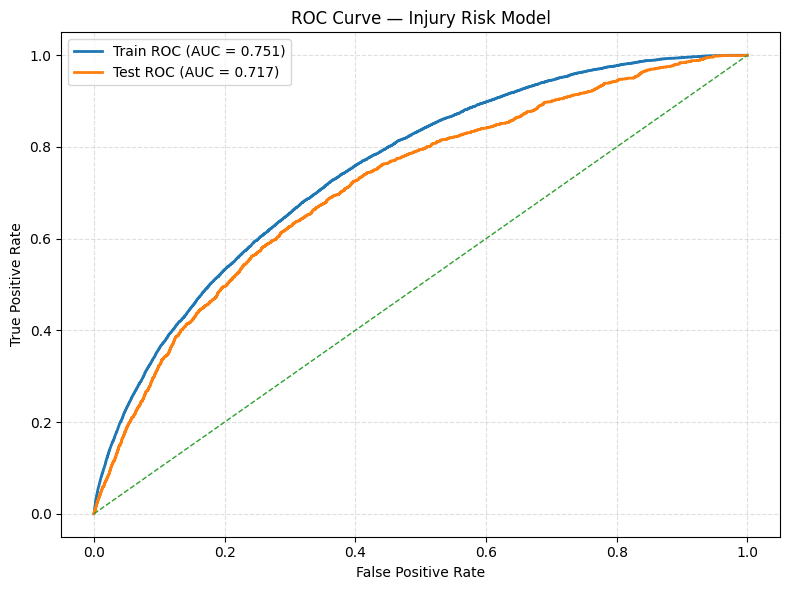

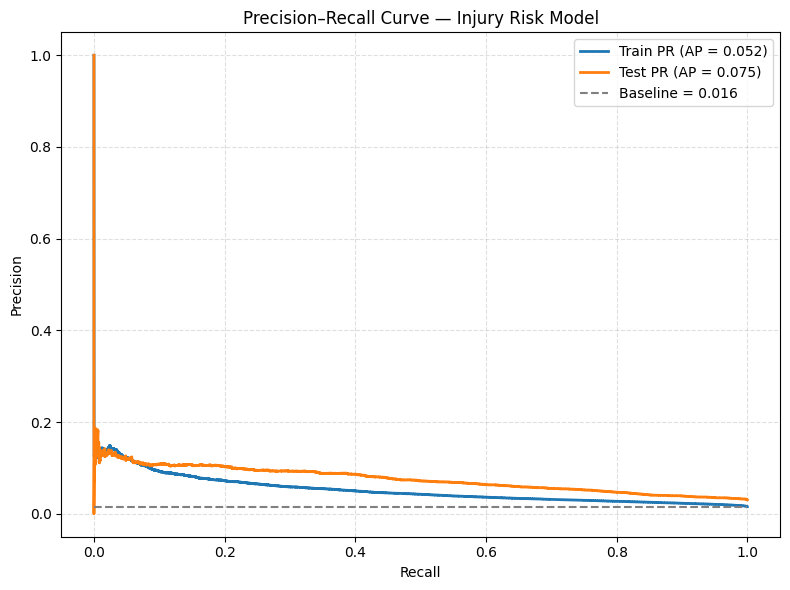

In [ ]:
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba  = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test,  y_test_proba)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Test  ROC-AUC: {test_auc:.4f}")


df["model_score"] = np.nan
df.loc[train_mask, "model_score"] = model.predict_proba(X_train)[:, 1]
df.loc[test_mask,  "model_score"] = model.predict_proba(X_test)[:, 1]
df["set"] = np.where(train_mask, "train", "test")

def plot_player_injury_risk(player_name, start_date="2023-01-01"):
    start_date = pd.to_datetime(start_date)

    pdf = (
        df[
            (df["player_name"] == player_name) &
            (df["gameDate_player"] >= start_date) &
            (df["set"] == "test")
        ]
        .sort_values("gameDate_player")
        .copy()
    )

    if pdf.empty:
        print(f"No test-set games found for {player_name} after {start_date.date()}.")
        return

    pdf["predicted_injury_prob"] = pdf["model_score"]

    daily = (
        pdf.set_index("gameDate_player")["predicted_injury_prob"]
           .resample("D").ffill()
           .reset_index()
           .rename(columns={"gameDate_player": "date"})
    )

    injury_dates = pdf.loc[pdf["injury_indicator"] == 1, "gameDate_player"].unique()

    plt.figure(figsize=(15, 6))

    plt.plot(
        daily["date"],
        daily["predicted_injury_prob"],
        label="Predicted Injury Risk (Daily, filled)",
        linewidth=2,
    )
    plt.scatter(
        pdf["gameDate_player"],
        pdf["predicted_injury_prob"],
        s=20,
        alpha=0.7,
        label="Game Days",
    )

    for i, d in enumerate(injury_dates):
        plt.axvline(
            x=d,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label="Injury Event" if i == 0 else "",
        )

    plt.title(f"Injury Probability Timeline — {player_name}", fontsize=16)
    plt.xlabel("Date")
    plt.ylabel("Predicted Injury Risk")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_random_players_with_injury(n_players=5, start_date="2022-10-01", seed=42):
    start_date = pd.to_datetime(start_date)

    injured_players = (
        df[(df["set"] == "test") & (df["injury_indicator"] == 1)]
        ["player_name"].dropna().unique()
    )
    if len(injured_players) == 0:
        print("No injured players in test set.")
        return

    n = min(n_players, len(injured_players))
    rng = np.random.default_rng(seed)
    sampled = rng.choice(injured_players, size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(16, 3.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, player_name in zip(axes, sampled):
        pdf = (
            df[
                (df["player_name"] == player_name) &
                (df["gameDate_player"] >= start_date) &
                (df["set"] == "test")
            ]
            .sort_values("gameDate_player")
            .copy()
        )
        if pdf.empty:
            continue

        pdf["predicted_injury_prob"] = pdf["model_score"]
        daily = (
            pdf.set_index("gameDate_player")["predicted_injury_prob"]
               .resample("D").ffill()
               .reset_index()
               .rename(columns={"gameDate_player": "date"})
        )
        injury_dates = pdf.loc[pdf["injury_indicator"] == 1, "gameDate_player"].unique()

        ax.plot(daily["date"], daily["predicted_injury_prob"], linewidth=2)
        ax.scatter(pdf["gameDate_player"], pdf["predicted_injury_prob"], s=15, alpha=0.7)

        for d in injury_dates:
            ax.axvline(x=d, color="red", linestyle="--", linewidth=1)

        ax.set_title(player_name)
        ax.set_ylabel("Risk")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

# plot_player_injury_risk("Anthony Davis", start_date="2022-10-01")
# plot_random_players_with_injury(n_players=5, start_date="2022-10-01")

# ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {train_auc:.3f})", linewidth=2)
plt.plot(fpr_test,  tpr_test,  label=f"Test ROC (AUC = {test_auc:.3f})",  linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Injury Risk Model")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

from sklearn.metrics import precision_recall_curve, average_precision_score

# PR curve plots
prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_proba)
prec_test,  rec_test,  _ = precision_recall_curve(y_test,  y_test_proba)

train_pr_auc = average_precision_score(y_train, y_train_proba)
test_pr_auc  = average_precision_score(y_test,  y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec_train, prec_train, label=f"Train PR (AP = {train_pr_auc:.3f})", linewidth=2)
plt.plot(rec_test,  prec_test,  label=f"Test PR (AP = {test_pr_auc:.3f})",  linewidth=2)

# Baseline: positive class frequency (class imbalance reference)
pos_rate = y_train.mean()
plt.hlines(pos_rate, 0, 1, colors="gray", linestyles="--", label=f"Baseline = {pos_rate:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Injury Risk Model")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

We can see that on our test and train sets the AUC score is around 0.7. Given our data imbalance, however, we chose to use AUPR score instead. We can see that this is far lower than the ROC-AUC score. A surprising observation is that the score is higher on the test set than on the train set. One of the reasons for this is different ratios of the classes in either set. In the train set, 1% of entries are class 1 whereas this value is 3% in the test set.

To optimize performance further, we scan through different thresholds to find the threshold that provides the best F1-score. The priority of the model is primarily to minimize false negatives, while also not having too many false positives. Overall, the threshold that yielded the best F1 score was 0.6844.

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.6, 0.9, 51)

rows = []
for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    rows.append([t, prec, rec, f1])

threshold_table = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])
threshold_table

,threshold,precision,recall,f1
0,0.6550,0.075409,0.463009,0.129695
1,0.6599,0.077402,0.451911,0.132167
2,0.6648,0.079689,0.442663,0.135064
3,0.6697,0.081053,0.427250,0.136256
4,0.6746,0.083437,0.414920,0.138935
5,0.6795,0.085929,0.401356,0.141553
6,0.6844,0.088252,0.387176,0.143740
7,0.6893,0.088064,0.364365,0.141846
8,0.6942,0.089569,0.344636,0.142185
9,0.6991,0.092015,0.331073,0.144006


Here we can see how different thresholds affect the confusion matrix of predictions.

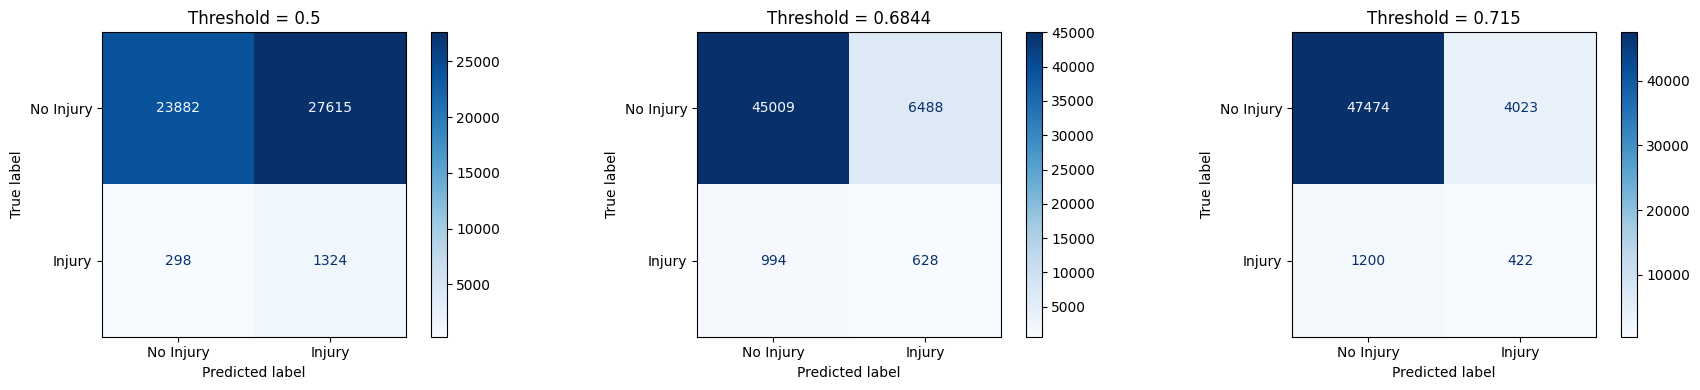

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = [0.50, 0.6844, 0.715]
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 4))

for ax, t in zip(axes, thresholds):
    y_pred = (y_test_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Injury", "Injury"])
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"Threshold = {t}")

plt.tight_layout()
plt.show()


## **Model Interpretability**

Below we compute the SHAP plots to see how the different features affect our model

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


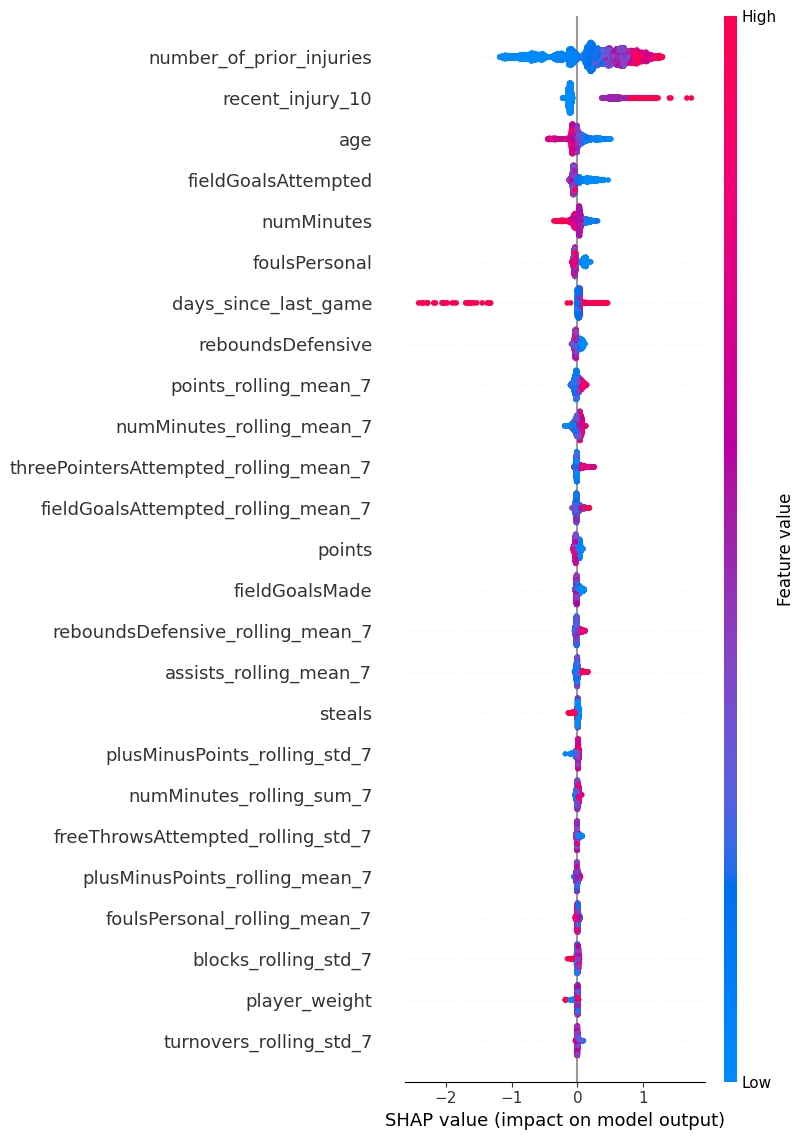

In [ ]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

n_sample = min(5000, len(X_test))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), n_sample, replace=False)
X_sample = X_test.iloc[idx]
shap_sample = shap_values_pos[idx]
shap.summary_plot(shap_sample, X_sample, plot_type="dot", max_display=25)

Looking at the SHAP plot we can see how different features affect the probability of next game. The top features are the number of prior injuries, and whether a player was injured in the last game. This aligns with the expected outcome as a player who has been injured in the past would be more likely to get the same injury again. One suprising variable, however, is age. According to the plot, the lower the age of a player the higher their probability of being injured. This is likely a result of a bias in the dataset. There are far more younger players in the NBA compared to the older veterans, thus dominating the number of injuries. Another insight is the number of days since the last game. Players with a lower number of days since the last game are more likely to get injured.

# **FAQs**
Below are answers to the questions we received:

**Question 1:** Why does temporal split matter for training and test splits?

**Answer:** Temporal splits are essential because our target—injury risk is inherently time-dependent. If we randomly split the data, the model could accidentally see future information about a player during training that influences predictions in the test set.

This creates data leakage, inflating performance metrics and making the model look better than it actually is. By training only on pre-2022 data and testing on 2022+, we simulate the real-world scenario. This preserves causal order and gives us a trustworthy estimate of real-world performance.

---

**Question 2:** Metrics seemed to drop for predicting those who had injury vs predicting who would not. Were there certain patients who were easier or more difficult to classify?

**Answer:** Injuries are a rare event, meaning the positive class is heavily imbalanced. Most players are not injured most of the time, so the model naturally becomes better at recognizing the majority class. Players also vary widely in risk profiles:

Some are extremely consistent and therefore easy to classify as “not injured”.

On the other hand, others have unpredictable injury histories or random acute injuries that hard to classify.

“High-variance” players (e.g., those returning from injury or playing inconsistent minutes) produce unstable patterns, which generates more false positives/negatives.

So the drop in performance is not just a model weakness—it's a fundamental challenge of rare-event prediction.

---
**Question 3:** Why does temporal split matter for training and test splits?

**Answer:** The model “remembers” past workload and injury history the most. Feature importance consistently shows that recent injuries, Minutes played and sudden workload spikes are the most important features, so although the index captures patterns the body should remember, it still underestimates unseen or qualitative stress factors. This is why a player with good recent stats might still get injured unexpectedly.

---

**Question 4:** Why did you need to merge three different datasets?

**Answer:** Injury prediction requires connecting three types of information that no single dataset contains.
The injury logs dataset contains dates, types and severitty of all injuries which provides us with the yes/no labels for the injury.
The game box scores dataset contains features such as minutes played, workload, performance and rest days. It hepls us to capture the leading indicators of inury risk. Moreover, the thrid one, add such information as age, heigh, weight and postition of a player, which serve as baseline risk factors for injury. Predicting injuries, using just one of the dataset would be a very challenging task.

---

**Question 5:** Does a Team Health Index help with specific actionable management? What do we think triggered the false positives in model performance?

**Answer:** The Team Health Index aggregates individual player risk into team-level readiness metrics. This allows management to:

- anticipate rotation strain,
- plan rest nights,
- understand roster fragility,
- create load-management strategies.

We believe that the most false positives came from:

- sudden workload spikes
- players returning from injury
- short-term anomalies (back-to-back games, overtime games)

In many cases, these patterns look like injury precursors even if no actual injury occurs.
False positives are quite common in rare-event prediction, because the model interprets stress as risk, even when the outcome is not guaranteed.
AI section:
When we encountered particularly stubborn bugs that were difficult to trace on our own, we used AI tools to help pinpoint potential issues and suggest targeted fixes, allowing us to stay efficient without relying on AI for routine debugging. We also turned to AI when we were unsure how to approach the significant class imbalance in our dataset; rather than experimenting blindly, we asked AI for a few high-level recommendations. It suggested options such as class-weighting, oversampling, and adjusting decision thresholds, which helped guide our thinking while still leaving the final decisions and implementations to us.


# **GenAI Policy**
When we encountered bugs that were difficult to trace on our own, we used AI tools to help pinpoint potential issues and suggest targeted fixes, allowing us to stay efficient without relying on AI for routine debugging. We also turned to AI when we were unsure how to approach the significant class imbalance in our dataset. We consulted AI for a few high-level recommendations. It suggested different approaches that we experimented with before finalizing our pipeline.